In [1]:
import pandas as pd
import numpy as np
import networkx as nx
from itertools import combinations, product
import matplotlib.pyplot as plt
import seaborn as sns
import copy
import os

from tqdm import tqdm
# from sdv.metadata import SingleTableMetadata
from numpy.core import multiarray
from sklearn.metrics import r2_score
from scipy.interpolate import CubicSpline, PchipInterpolator, Akima1DInterpolator

import torch
import torch.nn as nn
import torch.optim as optim
from scipy.optimize import minimize
from sklearn.preprocessing import MinMaxScaler, OrdinalEncoder
from sklearn.cluster import KMeans

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.api import ExponentialSmoothing


device = torch.device('cpu')

# plt.style.use('ggplot')
plt.style.use('default')

import matplotlib as mpl
#set params for the article
mpl.rcParams['xtick.labelsize'] = 16
mpl.rcParams['ytick.labelsize'] = 16
mpl.rcParams['legend.fontsize'] = 14
mpl.rcParams['axes.labelsize'] = 18

#set params for the notebook
# mpl.rcParams['xtick.labelsize'] = 12
# mpl.rcParams['ytick.labelsize'] = 12
# mpl.rcParams['legend.fontsize'] = 10
# mpl.rcParams['axes.labelsize'] = 14


# import category_encoders as ce

In [2]:
data = pd.read_csv('train_data.csv')

In [3]:
data = data.drop(['Этаж', 'Район', 'id', 'date', 'rooms', 'Цена', 'nprice'], axis=1)
data = data.drop(['metroprox', 'rwprox', 'medprox', 'kidprox', 'industrprox', 'Этажность объекта подземная', 'Этажность объекта наземная'], axis=1)
data['day'] = pd.to_datetime(data['day'])
data['month'] = data['day'].dt.month
data['year'] = data['day'].dt.year
data['day'] = data['day'].dt.day

data = data.drop(['day', 'month', 'year'], axis=1)
data = pd.concat([data['Квартиры среднего качества (типовые)'], data.drop('Квартиры среднего качества (типовые)', axis=1)], axis=1)

In [4]:
data = data.dropna()

In [5]:
data.shape

(253232, 17)

In [6]:
data.head()

,Квартиры среднего качества (типовые),Площадь квартиры,количество этажей всего,высота объекта,Количество квартир,Общая площадь объекта,Площадь жилых помещений объекта,lon,lat,floor,schoolprox,cemetprox,daysin,daycos,liveratio,highratio,pricemetr
0,1.648815,19.8,26.0,76.71,1056.0,76762.2,52066.5,37.348298,55.801606,2.0,0.001643,0.025956,-0.936881,-0.349647,0.678283,3.068400,0.295860
1,1.648815,50.8,26.0,76.71,1056.0,76762.2,52066.5,37.348298,55.801606,25.0,0.001643,0.025956,-0.972118,-0.234491,0.678283,3.068400,0.217977
2,1.644254,43.2,18.0,54.55,609.0,48074.8,34516.4,37.319359,55.638227,5.0,0.005334,0.044600,0.247022,-0.969010,0.717973,4.196154,0.214741
3,1.644254,39.7,18.0,54.55,609.0,48074.8,34516.4,37.319359,55.638227,10.0,0.005334,0.044600,0.213521,-0.976938,0.717973,4.196154,0.223181
4,1.644254,83.2,18.0,54.55,609.0,48074.8,34516.4,37.319359,55.638227,8.0,0.005334,0.044600,0.213521,-0.976938,0.717973,4.196154,0.182830


In [7]:
data = pd.concat([data.drop('pricemetr', axis=1), data['pricemetr']], axis=1)

In [8]:
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_percentage_error, r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler, MinMaxScaler

from deap import base, creator, tools, algorithms
import random

In [11]:
def train(X: pd.DataFrame, y: pd.Series, model):
    mape_arr = []
    r2_arr = []
    
    for _ in range(5):
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
        
        model.fit(X_train, y_train)
        prediction = model.predict(X_test)
        
        mape_arr.append(mean_absolute_percentage_error(y_test.values, prediction))
        r2_arr.append(r2_score(y_test.values, prediction))
        
    
    return {'mape_mean': round(np.mean(mape_arr), 3), 'mape_std': round(np.std(mape_arr), 4),\
            'r2_mean': round(np.mean(r2_arr), 3), 'r2_std': round(np.std(r2_arr), 4)}

In [9]:
X_ex, y_ex = data.drop('pricemetr', axis=1), data['pricemetr']

# xgb = XGBRegressor()

# train(X, y, xgb)

In [11]:
# model_list = zip([XGBRegressor(), RandomForestRegressor(), LinearRegression(), KNeighborsRegressor()], ['XGB', 'RF', 'LR', 'KNN'])

# for model, name in model_list:
#     print(name, train(X, y, model))

In [407]:
np.random.seed(55551)

def create_synth_dataset(n_samples, noise_std=0.1):
    X = np.random.rand(n_samples, 2)
    
    main_coef = np.array([2.0, 3.0])
    special_coef = np.array([2.0, -8.0])
    
    special_region1 = (X[:, 0] > 0.1) & (X[:, 0] < 0.3) & (X[:, 1] > 0.6) & (X[:, 1] < 0.8)
    special_region2 = (X[:, 0] > 0.6) & (X[:, 0] < 0.8) & (X[:, 1] > 0.3) & (X[:, 1] < 0.5)
    special_regions = special_region1 | special_region2
    
    y = X.dot(main_coef) + 7 + np.random.randn(n_samples) * noise_std
    y[special_regions] = X[special_regions].dot(special_coef) + X[special_regions][:, 0]**2 - 4 + np.random.randn(sum(special_regions)) * noise_std

    X = pd.DataFrame(X)
    y = pd.DataFrame(y)

    return X, y


# np.random.seed(55551)

# def create_synth_dataset(n_samples, noise_std=0.1):
#     X = np.random.rand(n_samples, 2)
    
#     main_coef = np.array([2.0, 3.0])
#     special_coef = np.array([2.0, -8.0])
    
#     special_region1 = (X[:, 0] > 0.1) & (X[:, 0] < 0.3) & (X[:, 1] > 0.5) & (X[:, 1] < 0.8)
#     special_region2 = (X[:, 0] > 0.5) & (X[:, 0] < 0.8) & (X[:, 1] > 0.3) & (X[:, 1] < 0.5)
#     special_regions = special_region1 | special_region2
    
#     y = X.dot(main_coef) + 7 + np.random.randn(n_samples) * noise_std
#     y[special_regions] = X[special_regions].dot(special_coef) + X[special_regions][:, 0]**2 - 4 + np.random.randn(sum(special_regions)) * noise_std

#     X = pd.DataFrame(X)
#     y = pd.DataFrame(y)

#     return X, y


# np.random.seed(55551)

# def create_synth_dataset(n_samples, noise_std=0.1):
#     X = np.random.rand(n_samples, 2)
    
#     main_coef = np.array([2.0, 3.0])
#     special_coef = np.array([2.0, -8.0])
    
#     special_region1 = (X[:, 0] > 0.1) & (X[:, 0] < 0.3) & (X[:, 1] > 0.2) & (X[:, 1] < 0.9)
#     special_region2 = (X[:, 0] > 0.3) & (X[:, 0] < 0.8) & (X[:, 1] > 0.3) & (X[:, 1] < 0.5)
#     special_regions = special_region1 | special_region2
    
#     y = X.dot(main_coef) + 7 + np.random.randn(n_samples) * noise_std
#     y[special_regions] = X[special_regions].dot(special_coef) + X[special_regions][:, 0]**2 - 4 + np.random.randn(sum(special_regions)) * noise_std

#     X = pd.DataFrame(X)
#     y = pd.DataFrame(y)

#     return X, y

In [ ]:
# X_ex, y_ex = create_synth_dataset(1000)

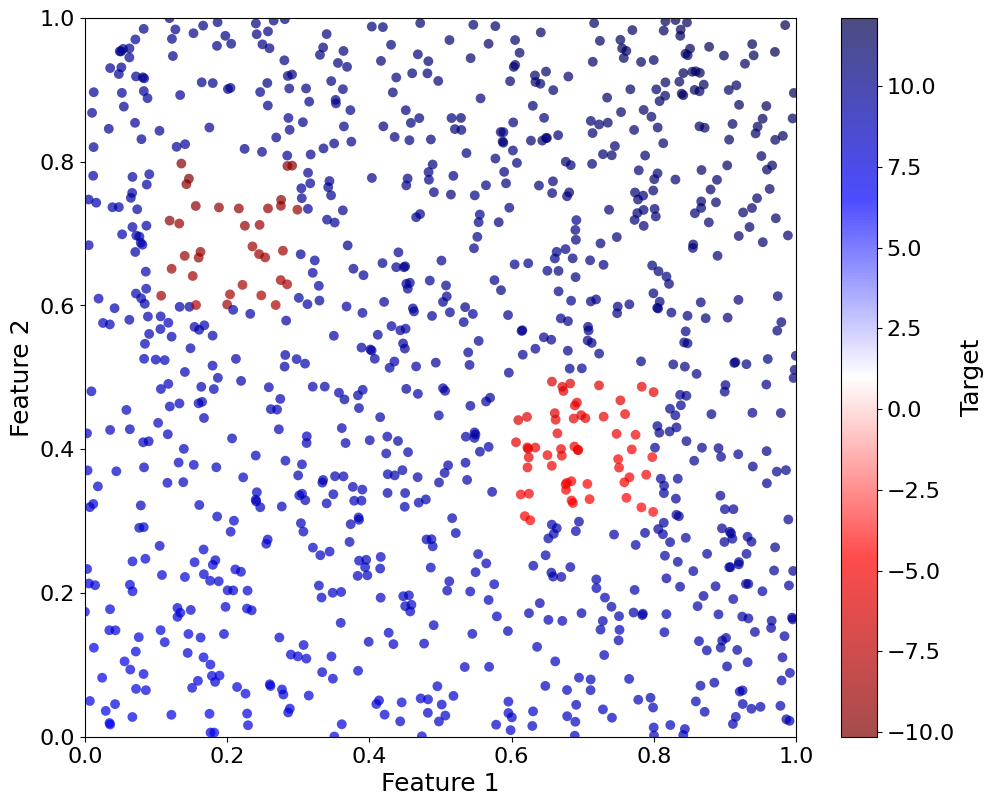

In [409]:
plt.figure(figsize=(10, 8))

sc = plt.scatter(X_ex.iloc[:, 0], X_ex.iloc[:, 1], c=y_ex, cmap='seismic_r', alpha=0.7, edgecolors='none', s=50)
plt.colorbar(sc, label='Target')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')

plt.xlim(0, 1)
plt.ylim(0, 1)
plt.tight_layout(pad=0.5)
# plt.savefig('images/synthetic_dataset.pdf', dpi=300)
plt.show()

In [379]:
# np.random.seed(55555)

# X_ex1 = np.concatenate([np.random.uniform(0.0, 0.199, (100)), np.random.uniform(0.301, 0.599, (360)), np.random.uniform(0.701, 1.0, (340))]).reshape(-1, 1)
# np.random.shuffle(X_ex1)

# X_ex2 = np.concatenate([np.random.uniform(0.0, 0.999, (360)), np.random.uniform(0.301, 0.799, (340)), np.random.uniform(0.901, 1.0, (100))]).reshape(-1, 1)
# np.random.shuffle(X_ex2)


# X_ex = np.concatenate([X_ex1, X_ex2], axis=1)

# X_ex = np.concatenate([X_ex, np.concatenate([np.random.uniform(0.2, 0.3, (30, 1)), np.random.uniform(0.0, 0.799, (30, 1))], axis=1)])
# X_ex = np.concatenate([X_ex, np.concatenate([np.random.uniform(0.2, 0.3, (30, 1)), np.random.uniform(0.901, 1.0, (30, 1))], axis=1)])
# X_ex = np.concatenate([X_ex, np.concatenate([np.random.uniform(0.6, 0.7, (30, 1)), np.random.uniform(0.0, 0.999, (30, 1))], axis=1)])
# X_ex = np.concatenate([X_ex, np.concatenate([np.random.uniform(0.6, 0.7, (30, 1)), np.random.uniform(0.301, 1.0, (30, 1))], axis=1)])

# y_ex = 2 * X_ex[:, 0] + 3 * X_ex[:, 1] + 4 + np.random.normal(0, 0.1, (1000 - 80))
# # y_ex[np.random.randint(0, 1000, 10)] = y_ex[np.random.randint(0, 1000, 10)] + np.random.normal(0, 1, (10))
# # y_ex[np.where((X_ex[:, 0] < 0.2) & (X_ex[:, 0] > 0.1))[0]] = y_ex[np.where((X_ex[:, 0] < 0.2) & (X_ex[:, 0] > 0.1))[0]] + np.random.normal(0, 2)


# X_ex_b = np.concatenate([np.random.uniform(0.2, 0.3, (30, 1)), np.random.uniform(0.8, 0.9, (30, 1))], axis=1)
# y_ex_b = 2 * X_ex_b[:, 0] + 8 * X_ex_b[:, 1] - 32
# X_ex = np.concatenate([X_ex_b, X_ex])
# y_ex = np.concatenate([y_ex_b, y_ex])

# X_ex_b = np.concatenate([np.random.uniform(0.6, 0.7, (50, 1)), np.random.uniform(0.1, 0.3, (50, 1))], axis=1)
# y_ex_b = 2 * X_ex_b[:, 0] - 3 * X_ex_b[:, 1] + 1
# X_ex = np.concatenate([X_ex_b, X_ex])
# y_ex = np.concatenate([y_ex_b, y_ex])


# X_ex = pd.DataFrame(X_ex)
# y_ex = pd.DataFrame(y_ex)

In [380]:
# plt.scatter(X_ex.iloc[:, 0], X_ex.iloc[:, 1])
# plt.show()

In [32]:
# num_columns = X_ex.select_dtypes(include=[np.number]).columns.tolist()
# cat_columns = np.setdiff1d(X_ex.columns, num_columns)
num_columns = np.setdiff1d(X_ex.columns, ['Квартиры среднего качества (типовые)'])
cat_columns = ['Квартиры среднего качества (типовые)']

length_cat_ordinal = len(cat_columns)
# length_cat_onehot = []
# # length_num = len(X.iloc[0])
length_num = len(num_columns)

length_dict = {'length_cat_ordinal': length_cat_ordinal, 'length_cat_onehot': [], 'length_num': length_num}

In [ ]:
# length_dict = {'length_cat_ordinal': 0, 'length_cat_onehot': [], 'length_num': 2}

## Baseline

In [30]:
def split_and_transform(X: pd.DataFrame, y: pd.DataFrame):
    scalers = {'scaler_X': MinMaxScaler(), 'scaler_y': MinMaxScaler(), 'ord_encoder': OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)}
    
    # X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
    X_train, X_test, y_train, y_test = X_train.reset_index(drop=True), X_test.reset_index(drop=True), y_train.reset_index(drop=True), y_test.reset_index(drop=True)
    
    if length_dict['length_cat_ordinal'] == 0:
        X_train = pd.DataFrame(scalers['scaler_X'].fit_transform(X_train))
        X_test = pd.DataFrame(scalers['scaler_X'].transform(X_test))
        y_train = pd.DataFrame(scalers['scaler_y'].fit_transform(y_train.values.reshape(-1, 1)))
        y_test = pd.DataFrame(scalers['scaler_y'].transform(y_test.values.reshape(-1, 1)))
        
        
    elif length_dict['length_cat_ordinal'] != 0:
        X_train[cat_columns] = pd.DataFrame(scalers['ord_encoder'].fit_transform(X_train[cat_columns]))
        X_test[cat_columns] = pd.DataFrame(scalers['ord_encoder'].transform(X_test[cat_columns]))
        
        X_train[num_columns] = pd.DataFrame(scalers['scaler_X'].fit_transform(X_train[num_columns]))
        X_test[num_columns] = pd.DataFrame(scalers['scaler_X'].transform(X_test[num_columns]))
        
        y_train = pd.DataFrame(scalers['scaler_y'].fit_transform(y_train.values.reshape(-1, 1)))
        y_test = pd.DataFrame(scalers['scaler_y'].transform(y_test.values.reshape(-1, 1)))
        
    return X_train, X_test, y_train, y_test, scalers


def train_model(model_type, X_train, y_train):
    model = model_type
    model.fit(X_train.values, y_train.values)
    
    return model


def evaluate_model(model_type, X, y):
    metrics = {'mse': [], 'r2': [], 'mape': []}
    
    for _ in range(31):
        X_train, X_test, y_train, y_test, scalers = split_and_transform(X, y)
        model = train_model(model_type, X_train, y_train)
        
        prediction = model.predict(X_test)
    
        metrics['mse'].append(mean_squared_error(y_test.values, prediction))
        metrics['r2'].append(r2_score(y_test.values, prediction))
        metrics['mape'].append(mean_absolute_percentage_error(y_test.values, prediction))
    
    metrics_df = pd.DataFrame([[np.mean(metrics['mse']), np.std(metrics['mse'])],
                               [np.mean(metrics['r2']), np.std(metrics['r2'])],
                               [np.mean(metrics['mape']), np.std(metrics['mape'])]], columns=['MEAN', 'STD'], index=['mse', 'r2', 'mape'])
        
    return metrics_df.round(3)

In [33]:
X_train, X_test, y_train, y_test, scalers = split_and_transform(X_ex, y_ex)

In [35]:
baseline_model = train_model(LinearRegression(), X_train, y_train)
new_model = train_model(XGBRegressor(), X_train, y_train)

In [36]:
baseline_prediction = baseline_model.predict(X_test).flatten()

In [434]:
evaluate_model(XGBRegressor(), X_ex, y_ex)

,MEAN,STD
mse,0.000,0.000
r2,0.863,0.009
mape,0.096,0.013


In [388]:
# scaler_X_train = MinMaxScaler()
# scaler_y_train = MinMaxScaler()
# data = pd.DataFrame(scaler.fit_transform(data), columns=data.columns)

# X_train, X_test, y_train, y_test = train_test_split(data.drop('pricemetr', axis=1), data['pricemetr'], test_size=0.2, random_state=55555)
# X_train, X_test, y_train, y_test = train_test_split(X_ex, y_ex, test_size=0.2, random_state=55555)

# X_train = pd.DataFrame(scaler_X_train.fit_transform(X_train))
# X_test = pd.DataFrame(scaler_X_train.transform(X_test))
# y_train = pd.DataFrame(scaler_y_train.fit_transform(y_train.values.reshape(-1, 1)))
# y_test = pd.DataFrame(scaler_y_train.transform(y_test.values.reshape(-1, 1)))


# xgb = XGBRegressor()
# xgb = LinearRegression()

# xgb.fit(X_train, y_train)

In [389]:
# new_reg_model = XGBRegressor()
# new_reg_model.fit(X_train, y_train)

In [390]:
# xgb_pred = xgb.predict(X_test)

In [391]:
# plt.scatter(y_test.values, xgb_pred)
# plt.plot(np.linspace(0, 0.6, 10), np.linspace(0, 0.6, 10), color='black')
# plt.show()

## Select bad examples

In [11]:
def select_bad_examples(X: pd.DataFrame, y: pd.DataFrame, predictions: np.array, thrs: float = 0.05):
    idx_bad = np.where(np.abs(y.values.flatten() - predictions.flatten()) >= thrs)[0]
    bad_y = y.iloc[idx_bad]
    bad_X = X.iloc[idx_bad]
    
    return bad_X, bad_y

In [115]:
bad_X, bad_y = select_bad_examples(X_test, y_test, baseline_prediction, 0.05)

In [116]:
len(bad_X) / len(X_test)

0.038541275889983614

In [117]:
bad_X

,Квартиры среднего качества (типовые),Площадь квартиры,количество этажей всего,высота объекта,Количество квартир,Общая площадь объекта,Площадь жилых помещений объекта,lon,lat,floor,schoolprox,cemetprox,daysin,daycos,liveratio,highratio
0,2.0,0.127520,0.477778,0.414070,0.315120,0.480407,0.431999,0.626388,0.466473,0.092105,0.072613,0.431407,0.020637,0.357809,0.271615,0.025037
3,19.0,0.383731,0.144444,0.136223,0.019461,0.023866,0.031305,0.467354,0.485496,0.026316,0.084785,0.673923,0.066268,0.748752,0.548724,0.041491
30,9.0,0.100795,0.300000,0.228633,0.419536,0.195354,0.365622,0.623445,0.438500,0.013158,0.140160,0.491797,0.452731,0.002221,0.799164,0.017009
33,3.0,0.017984,0.233333,0.198087,0.086078,0.093298,0.125287,0.687389,0.558890,0.000000,0.051971,0.220585,0.410116,0.008127,0.524216,0.022867
53,19.0,0.016729,0.655556,0.564209,0.200225,0.176618,0.274242,0.467019,0.543605,0.000000,0.077880,0.668850,0.052076,0.277798,0.629093,0.018834
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
50526,8.0,0.067754,0.300000,0.228633,0.419536,0.195354,0.365622,0.623445,0.438500,0.013158,0.140160,0.491797,0.610962,0.987532,0.799164,0.017009
50542,25.0,0.165203,0.288889,0.278309,0.160928,0.261449,0.343835,0.545193,0.609542,0.276316,0.025104,0.307637,0.009342,0.596218,0.499397,0.034395
50564,11.0,0.535717,0.155556,0.182660,0.023952,0.029256,0.054775,0.522619,0.577262,0.078947,0.029807,0.035074,0.482789,0.999704,0.810060,0.048910
50632,4.0,0.157675,0.188889,0.120673,0.113772,0.086875,0.146762,0.461956,0.631116,0.131579,0.064113,0.648542,0.955307,0.293348,0.706418,0.018962


In [118]:
# idx_bad = np.where(np.abs(y_test.values - xgb_pred) > 0.05)[0]
# bad_y = y_test.iloc[idx_bad]
# bad_X = X_test.loc[y_test.iloc[idx_bad].index]

In [119]:
bad_X.shape

(1952, 16)

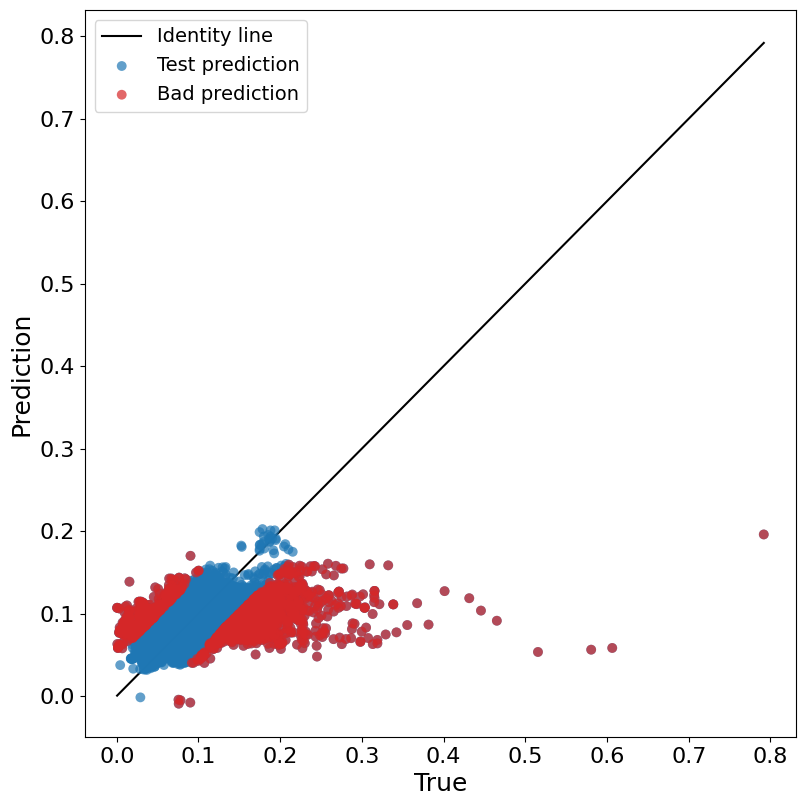

In [120]:
plt.figure(figsize=(8, 8))

plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='black', label='Identity line')
plt.scatter(y_test.values, baseline_prediction, color='tab:blue', alpha=0.7, label='Test prediction', zorder=3, edgecolors='none', s=50)
plt.scatter(bad_y, baseline_model.predict(bad_X), color='tab:red', alpha=0.7, label='Bad prediction', zorder=3, edgecolors='none', s=50)

plt.xlabel('True')
plt.ylabel('Prediction')
plt.legend()

plt.tight_layout(pad=0.5)
# plt.savefig('images/prediction_bad_moscow.pdf', dpi=300)
plt.show()

In [25]:
# plt.figure(figsize=(8, 8))

# plt.scatter(X_ex.iloc[:, 0], X_ex.iloc[:, 1], alpha=0.7, edgecolors='none', s=50, color='tab:blue', label='Good points')
# plt.scatter(bad_X.iloc[:, 0], bad_X.iloc[:, 1], color='red', alpha=0.7, edgecolors='none', s=50, label='Bad points')

# plt.xlabel('Feature 1')
# plt.ylabel('Feature 2')

# plt.xlim(0, 1)
# plt.ylim(0, 1)
# plt.legend()
# plt.tight_layout(pad=0.5)
# # plt.savefig('images/bad_X.pdf', dpi=300)
# plt.show()

In [1133]:
# bad_data = data.loc[bad_y.index]

In [565]:
# low = [0.0] * 10
# up = [1.0] * 10
# num1_copy = [0.3, 0.4, 0.4, 0.5, 0.1]
# num2_copy = [0.1, 0.1, 0.8, 0.8, 0.9]

# tools.cxTwoPoint(num1_copy, num2_copy)
# tools.cxUniform(num1_copy, num2_copy, indpb= 0.4)
# tools.cxUniform([0, 0, 1], [1, 0, 0], indpb= 0.4)

In [172]:
# import random
# from deap import tools

# def cxOneHotOX(ind1, ind2, feature_sizes):
#     """
#     Order-Based Crossover (OX) для OneHot-кодированных признаков.
    
#     Args:
#         ind1: первая особь (list)
#         ind2: вторая особь (list)
#         feature_sizes: список размеров каждого OneHot-блока
        
#     Returns:
#         Кортеж из двух особей с сохранением валидности OneHot-векторов
#     """
#     # Проверяем, что особи одинаковой длины
#     assert len(ind1) == len(ind2), "Особи должны быть одинаковой длины"
    
#     # Создаем копии для безопасности
#     child1 = ind1[:]
#     child2 = ind2[:]
    
#     # Определяем границы блоков
#     boundaries = []
#     start = 0
#     for size in feature_sizes:
#         end = start + size
#         boundaries.append((start, end))
#         start = end
    
#     # Для каждого признака (блока) применяем OX
#     for start, end in boundaries:
#         # Выбираем случайные точки разрыва в пределах блока
#         if end - start < 2:
#             continue  # Пропускаем блоки размером 1
            
#         a, b = random.sample(range(start, end), 2)
#         point1, point2 = min(a, b), max(a, b)
        
#         # Копируем сегменты между точками разрыва
#         segment1 = child1[point1:point2]
#         segment2 = child2[point1:point2]
        
#         # Создаем маски для определения позиций единиц
#         ones_pos1 = [i for i in range(start, end) if child1[i] == 1]
#         ones_pos2 = [i for i in range(start, end) if child2[i] == 1]
        
#         # Заменяем сегменты
#         child1[point1:point2] = segment2
#         child2[point1:point2] = segment1
        
#         # Восстанавливаем валидность OneHot-векторов
#         repair_onehot_block(child1, start, end, ones_pos1)
#         repair_onehot_block(child2, start, end, ones_pos2)
    
#     return child1, child2

# def repair_onehot_block(individual, start, end, original_ones_pos):
#     """
#     Восстанавливает валидность OneHot-блока после скрещивания.
#     """
#     block = individual[start:end]
    
#     # Проверяем сумму элементов в блоке
#     block_sum = sum(block)
    
#     if block_sum == 1:
#         return  # Блок уже валиден
    
#     if block_sum == 0:
#         # Если все элементы нулевые, восстанавливаем исходную позицию единицы
#         if original_ones_pos and start <= original_ones_pos[0] < end:
#             individual[original_ones_pos[0]] = 1
#         else:
#             # Или выбираем случайную позицию
#             pos = random.randint(start, end-1)
#             individual[pos] = 1
    
#     elif block_sum > 1:
#         # Если больше одной единицы, оставляем только одну
#         ones_positions = [i for i in range(start, end) if individual[i] == 1]
        
#         # Оставляем только первую единицу, остальные обнуляем
#         for i, pos in enumerate(ones_positions):
#             if i == 0:
#                 continue  # Первую единицу оставляем
#             individual[pos] = 0

# # Пример использования в DEAP
# toolbox.register("mate", cxOneHotOX, feature_sizes=[3, 4, 2])  # Пример: 3 признака с 3, 4 и 2 категориями

In [ ]:
# def cxOneHotByFeature(ind1, ind2, feature_sizes):
#     child1 = ind1[:]
#     child2 = ind2[:]
    
#     start = 0
#     for size in feature_sizes:
#         end = start + size
#         if random.random() < 0.5:  # 50% chance to swap the feature
#             child1[start:end], child2[start:end] = child2[start:end], child1[start:end]
#         start = end
    
#     return child1, child2

In [12]:
def custom_crossover_num(ind1, ind2, num_eta=10):
    num1_copy = copy.deepcopy(ind1)
    num2_copy = copy.deepcopy(ind1)

    low = [0.0] * len(num1_copy)
    up = [1.0] * len(num1_copy)
    tools.cxSimulatedBinaryBounded(num1_copy, num2_copy, eta=num_eta, low=low, up=up)

    ind1 = num1_copy
    ind2 = num2_copy

    return ind1, ind2


def custom_crossover_num_ord(ind1, ind2, cat_indpb=0.3, num_eta=10):
    cat1 = ind1[:length_cat_ordinal]
    cat2 = ind2[:length_cat_ordinal]
    num1 = ind1[length_cat_ordinal:]
    num2 = ind2[length_cat_ordinal:]

    cat1_copy = copy.deepcopy(list(cat1))
    cat2_copy = copy.deepcopy(list(cat2))
    num1_copy = copy.deepcopy(list(num1))
    num2_copy = copy.deepcopy(list(num2))

    tools.cxUniform(cat1_copy, cat2_copy, indpb=cat_indpb)

    low = [0.0] * len(num1_copy)
    up = [1.0] * len(num1_copy)
    tools.cxSimulatedBinaryBounded(num1_copy, num2_copy, eta=num_eta, low=low, up=up)

    ind1[:] = cat1_copy + num1_copy
    ind2[:] = cat2_copy + num2_copy

    return ind1, ind2


# def custom_crossover_num_ord_nominal(ind1, ind2, cat_indpb=0.3, num_eta=10):
#     onehot1 = ind1[:sum(length_cat_onehot)]
#     onehot2 = ind2[:sum(length_cat_onehot)]
#     cat1 = ind1[sum(length_cat_onehot) : sum(length_cat_onehot) + length_cat_ordinal]
#     cat2 = ind2[sum(length_cat_onehot) : sum(length_cat_onehot) + length_cat_ordinal]
#     num1 = ind1[-length_num:]
#     num2 = ind2[-length_num:]

#     cat1_copy = copy.deepcopy(list(cat1))
#     cat2_copy = copy.deepcopy(list(cat2))
#     num1_copy = copy.deepcopy(list(num1))
#     num2_copy = copy.deepcopy(list(num2))

#     tools.cxUniform(cat1_copy, cat2_copy, indpb=cat_indpb)

#     low = [0.0] * len(num1_copy)
#     up = [1.0] * len(num1_copy)
#     tools.cxSimulatedBinaryBounded(num1_copy, num2_copy, eta=num_eta, low=low, up=up)

#     ind1[:] = cat1_copy + num1_copy
#     ind2[:] = cat2_copy + num2_copy

#     return ind1, ind2

In [75]:
def custom_mutate_num(individual, weights, linear_coefs, target_direction, base_mutation_rate=0.8, mutation_strength=0.5):
    for i in range(len(individual)):
        mutation_prob = base_mutation_rate # * weights[i]
        
        if random.random() < mutation_prob:
            coef = linear_coefs[i]
            direction = 1 if coef * target_direction >= 0 else -1
            
            # noise = direction * abs(np.random.normal(0, weights[i] * mutation_strength))
            noise = direction * abs(np.random.normal(0, 0.1 * mutation_strength))
            individual[i] = max(0, min(1, individual[i] + noise))
                
    return individual,


def custom_mutate_num_ord(individual, bad_X, weights, linear_coefs, target_direction, base_mutation_rate=0.8, mutation_strength=0.5):
    for i in range(len(individual)):
        mutation_prob = base_mutation_rate #* weights[i]
        
        if random.random() < mutation_prob:
            if i < length_dict['length_cat_ordinal']: 
                individual[i] = random.sample(list(bad_X.iloc[i].unique()), 1)[0]
            else: 
                # idx = i - len(cat_cols_name)
                coef = linear_coefs[i]
                
                direction = 1 if coef * target_direction >= 0 else -1
                
                # noise = direction * abs(np.random.normal(0, weights[i] * mutation_strength))
                noise = direction * abs(np.random.normal(0, 0.1 * mutation_strength))
                individual[i] = max(0, min(1, individual[i] + noise))
                
    return individual,


# def custom_mutate(individual, weights, linear_coefs, target_direction, base_mutation_rate=0.8, mutation_strength=0.5):
#     for i in range(len(individual)):
#         mutation_prob = base_mutation_rate * weights[i]
        
#         if random.random() < mutation_prob:
#             if i < len(cat_cols_name): 
#                 individual[i] = random.sample(list(X_exp[cat_cols_name[i]].unique()), 1)[0]
#             else: 
#                 # idx = i - len(cat_cols_name)
#                 coef = linear_coefs[i]
                
#                 direction = 1 if coef * target_direction >= 0 else -1
                
#                 noise = direction * abs(np.random.normal(0, weights[i] * mutation_strength))
#                 individual[i] = max(0, min(1, individual[i] + noise))
                
#     return individual,

In [ ]:
lr = LinearRegression(fit_intercept=False)
lr.fit(X_train.values, y_train.values)
linear_coefs = lr.coef_[0]

In [76]:
def augmentation(bad_X, bad_y, baseline_model, linear_coefs, length_dict, num_steps: int = 10):
    creator.create("FitnessMax", base.Fitness, weights=(1.0,))
    creator.create("Individual", list, fitness=creator.FitnessMax)
    toolbox = base.Toolbox()

    if (length_dict['length_cat_ordinal'] == 0) and (length_dict['length_cat_onehot'] == []):
        for i in range(length_dict['length_num']):
            # toolbox.register(f"num_{i}", random.uniform, 0.0, 1.0)
            toolbox.register(f"num_{i}", random.sample, list(bad_X.iloc[:, i].unique()), 1)
            
        def make_individual():
            return creator.Individual(np.hstack([toolbox.__getattribute__(f"num_{i}")() for i in range(length_dict['length_num'])]))
            
        toolbox.register("individual", tools.initIterate, creator.Individual, make_individual)
        toolbox.register("population", tools.initRepeat, list, toolbox.individual)
        toolbox.register("mate", custom_crossover_num)
            
            
    elif (length_dict['length_cat_ordinal'] != 0) and (length_dict['length_cat_onehot'] == []):
        for i in range(len(cat_columns)):
            toolbox.register(f"cat_{i}", random.sample, list(bad_X.iloc[:, i].unique()), 1)
            
        for i in range(length_cat_ordinal, length_cat_ordinal + length_dict['length_num']):
            # toolbox.register(f"num_{i}", random.uniform, 0.0, 1.0)
            toolbox.register(f"num_{i - length_cat_ordinal}", random.sample, list(bad_X.iloc[:, i].unique()), 1)
            
        def make_individual():
            return np.hstack([toolbox.__getattribute__(f"cat_{i}")() for i in range(length_cat_ordinal)] + \
                [toolbox.__getattribute__(f"num_{i}")() for i in range(length_dict['length_num'])])
            
        toolbox.register("individual", tools.initIterate, creator.Individual, make_individual)
        toolbox.register("population", tools.initRepeat, list, toolbox.individual)
        toolbox.register("mate", custom_crossover_num_ord)
        
        
    else:
        return 0
        # for i, col in enumerate(cat_cols_name):
        #     toolbox.register(f"cat_{i}", random.sample, list(X[col].unique()), 1)
        
        # for i, col in enumerate(cat_cols_name):
        #     toolbox.register(f"cat_{i}", random.sample, list(X[col].unique()), 1)
            
        # for i in range(length_num):
        #     # toolbox.register(f"num_{i}", random.uniform, 0.0, 1.0)
        #     toolbox.register(f"num_{i}", random.sample, list(bad_X.iloc[:, i].unique()), 1)
            
        # def make_individual():
        #     return 0
            
        # toolbox.register("individual", tools.initIterate, creator.Individual, make_individual)
        # toolbox.register("population", tools.initRepeat, list, toolbox.individual)
        # toolbox.register("mate", custom_crossover_num_ord_nominal)
        
        


    # def make_individual():
    #     if (length_cat_ordinal == 0) and (length_cat_onehot == []):
    #         return np.hstack([toolbox.__getattribute__(f"num_{i}")() for i in range(length_num)])
            
    #     elif (length_cat_ordinal != 0) and (length_cat_onehot == []):
    #         return np.hstack([toolbox.__getattribute__(f"cat_{i}")() for i in range(length_cat_ordinal)] + \
    #             [toolbox.__getattribute__(f"num_{i}")() for i in range(length_num)])
            
    #     else:
    #         return 0

    toolbox.register("select", tools.selTournament, tournsize=3)
    
    steps = tqdm(range(len(bad_X)))
    best_individuals = []
    bad_y_sc_arr = []
    prediction_exp = baseline_model.predict(bad_X)
    
    

    for _ in range(num_steps):
        bad_y_scenario = np.maximum(np.minimum(0.0, y_test.min().values[0]),
                                    np.minimum(bad_y + np.random.normal(0, 0.01, (len(bad_y), 1)), np.maximum(1.0, y_test.max().values[0])))
        # bad_y_scenario = bad_y
        
        for i in steps:
            def eval_func(individual, y_target, linear_coefs, weights, target_direction, bonus_factor = 0.9):
                prediction = baseline_model.predict([individual])
                error = 0.5 * (prediction[0] - y_target.values[i])**2 - np.mean( (individual - bad_X.values[i])**2 )
                # bonus = 0
                # for k, val in enumerate(individual):
                #     # if k > len(cat_cols_name):
                #         coef = linear_coefs[k]
                #         base_val = X_exp.loc[idx_sc].iloc[i, k+1]
                        
                
                #         if coef * target_direction >= 0:  # Увеличение признака повышает таргет
                #             if val > base_val:
                #                 bonus += weights[k] * (val - base_val) * bonus_factor
                #         elif coef * target_direction < 0:  # Уменьшение признака повышает таргет
                #             if val < base_val:
                #                 bonus += weights[k] * (base_val - val) * bonus_factor
                                
                total_fitness = error #+ bonus
                return (total_fitness,)
            
            def main(target_direction, y_target):
                toolbox.register("evaluate", eval_func, y_target=y_target, 
                                linear_coefs=linear_coefs, weights=1, target_direction=target_direction)
                # toolbox.unregister("mutate")
                if length_dict['length_cat_ordinal'] == 0:
                    toolbox.register("mutate", custom_mutate_num, weights=1, linear_coefs=linear_coefs, 
                                target_direction=target_direction)
                else:
                    toolbox.register("mutate", custom_mutate_num_ord, bad_X=bad_X, weights=1, linear_coefs=linear_coefs, 
                                target_direction=target_direction)

                pop = toolbox.population(n=30)
                hof = tools.HallOfFame(1, similar=np.array_equal)
                stats = tools.Statistics(lambda ind: ind.fitness.values)
                stats.register("avg", lambda x: sum(i[0] for i in x)/len(x))
                stats.register("max", lambda x: max(i[0] for i in x))

                algorithms.eaSimple(pop, toolbox, 0.1, 0.1, 10, stats=stats, halloffame=hof, verbose=False)
                
                return hof[0]
        
            if bad_y_scenario.values[i] >= prediction_exp[i]:
                target_direction = 1
            else:
                target_direction = -1
            
            
            best_individual = main(target_direction, bad_y_scenario)
            best_individuals.append(best_individual)
            
        bad_y_sc_arr.append(bad_y_scenario.values.flatten())
        
    bad_y_sc_arr = np.hstack(bad_y_sc_arr)
    best_individuals = np.array(best_individuals)
    
    return best_individuals, bad_y_sc_arr

In [574]:
best_individuals, bad_y_sc_arr = augmentation(bad_X, bad_y, baseline_model, linear_coefs, length_dict, num_steps=10)

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/deap/creator.py:185: RuntimeWarning: A class named 'FitnessMax' has already been created and it will be overwritten. Consider deleting previous creation of that class or rename it.
  warnings.warn("A class named '{0}' has already been created and it "
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/deap/creator.py:185: RuntimeWarning: A class named 'Individual' has already been created and it will be overwritten. Consider deleting previous creation of that class or rename it.
  warnings.warn("A class named '{0}' has already been created and it "


  0%|          | 0/246 [00:00<?, ?it/s]

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(


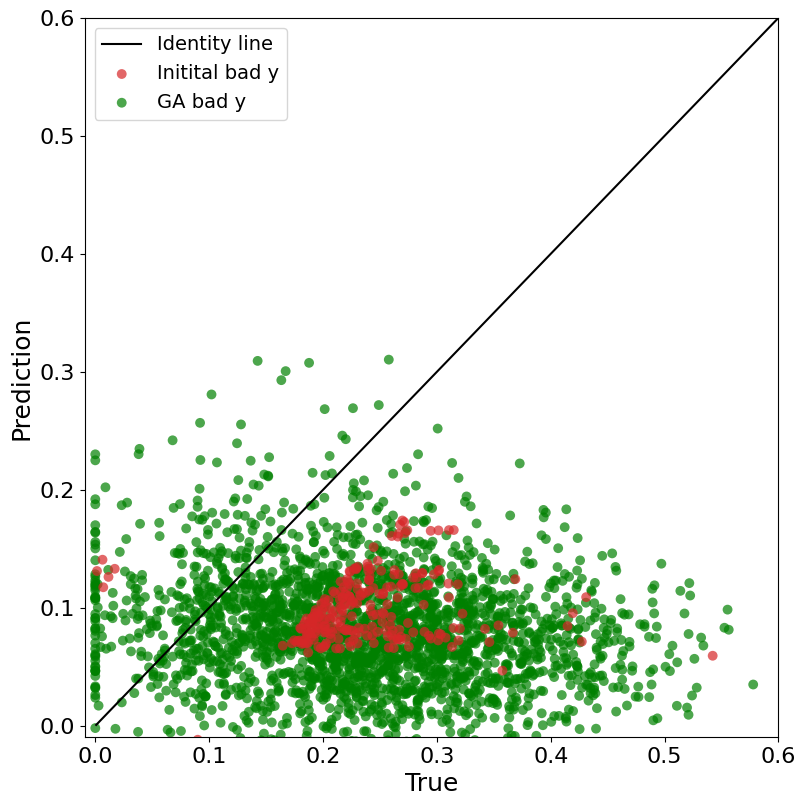

In [575]:
plt.figure(figsize=(8, 8))

plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='black', label='Identity line')
plt.scatter(bad_y, baseline_model.predict(bad_X), alpha=0.7, label='Initital bad y', color='tab:red', zorder=3, edgecolors='none', s=50)
plt.scatter(bad_y_sc_arr, baseline_model.predict(best_individuals), alpha=0.7, label='GA bad y', color='green', edgecolors='none', s=50)

plt.xlabel('True')
plt.ylabel('Prediction')
plt.legend()
plt.ylim((y_test.min().values - 0.01, 0.6))
plt.xlim((y_test.min().values - 0.01, 0.6))

plt.tight_layout(pad=0.5)
# plt.savefig('images/prediction_best_ind_moscow_0_02.pdf', dpi=300)
plt.show()

In [174]:
# plt.figure(figsize=(8, 8))

# plt.scatter(X_ex.iloc[:, 0], X_ex.iloc[:, 1], alpha=0.7, edgecolors='none', s=50, color='tab:blue', label='Good points')
# plt.scatter(best_individuals[:, 0], best_individuals[:, 1], color='green', alpha=0.7, edgecolors='none', s=50, label='GA points')
# plt.scatter(bad_X.iloc[:, 0], bad_X.iloc[:, 1], color='red', alpha=0.7, edgecolors='none', s=50, label='Bad points')

# plt.xlabel('Feature 1')
# plt.ylabel('Feature 2')

# plt.xlim(0, 1)
# plt.ylim(0, 1)
# plt.legend()
# plt.tight_layout(pad=0.5)
# # plt.savefig('images/GA_points.pdf', dpi=300)
# plt.show()

In [576]:
y_test.min().values

array([0.0007624])

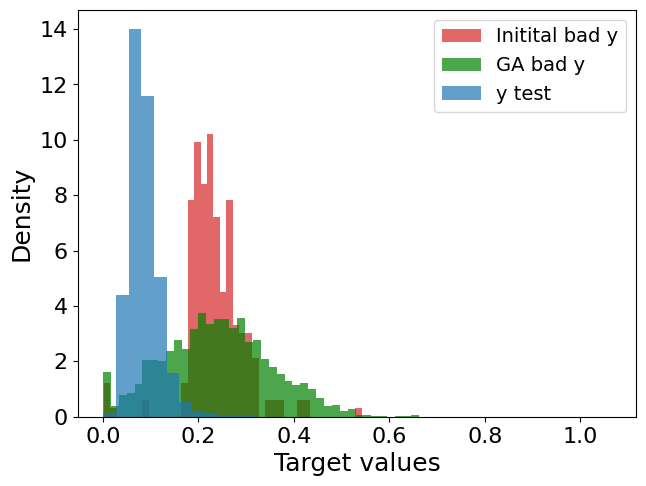

In [ ]:
plt.hist(bad_y, bins=40, density=True, alpha=0.7, label='Initital bad y', color='tab:red')
plt.hist(bad_y_sc_arr, bins=40, density=True, alpha=0.7, label='GA bad y', color='green')
plt.hist(y_test, bins=40, density=True, alpha=0.7, label='y test', color='tab:blue')


plt.legend()
plt.xlabel('Target values')
plt.ylabel('Density')

plt.tight_layout(pad=0.5)
# plt.savefig('images/hist_ga_moscow_0_1.pdf', dpi=300)
plt.show()

In [26]:
# for i in range(len(X_train.columns)):
#     plt.hist(X_ex.iloc[:, i], bins=40, alpha=0.6, label='Initital X', color='black', density=True)
#     plt.hist(bad_X.iloc[:, i], bins=40, alpha=0.6, label='Initital bad X', color='tab:red', density=True)
#     plt.hist(np.array(best_individuals)[:, i], bins=40, alpha=0.6, label='Scenario bad X', color='tab:blue', density=True)

#     plt.legend()
#     plt.show()

In [408]:
# plt.subplots(figsize=(10, 5))

# vis_arr1 = []
# vis_arr2 = []

# for col in X_exp.columns.values:
#     vis_arr1.append((data.loc[idx_sc, col]/data.loc[idx_sc, col].max()).mean())
#     vis_arr2.append((scenario_df_GA[col]/scenario_df_GA[col].max()).mean())
#     # 
# plt.bar(X_exp.columns, vis_arr1, alpha=0.6, color='tab:blue', label='Initial data')
# plt.bar(X_exp.columns, vis_arr2, alpha=0.6, color='tab:red', label='Synth data')

# plt.xticks(rotation=90, fontsize=10)
# plt.ylabel('Mean value')
# plt.legend()
# plt.show()

In [57]:
bad_X_ga, bad_y_ga = select_bad_examples(pd.DataFrame(best_individuals), pd.DataFrame(bad_y_sc_arr), baseline_model.predict(best_individuals))

In [58]:
idx_rnd = np.arange(len(bad_X) + len(bad_X_ga))
np.random.shuffle(idx_rnd)

augmented_X = np.concatenate([bad_X.values, bad_X_ga.values])[idx_rnd]
augmented_y = np.concatenate([bad_y.values.flatten(), bad_y_ga.values.flatten()])[idx_rnd]

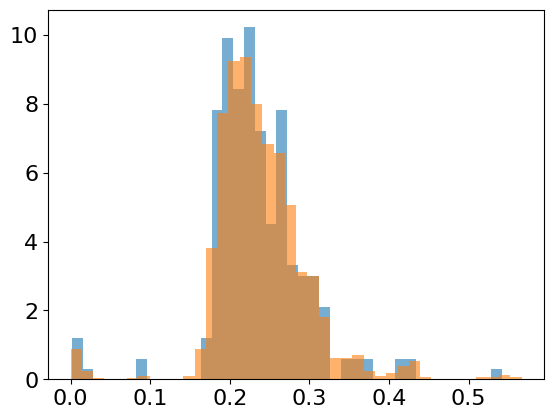

In [59]:
# plt.hist(y_test, density=True, alpha=0.6, bins=40)
plt.hist(bad_y, density=True, alpha=0.6, bins=40)
plt.hist(augmented_y, bins=40, density=True, alpha=0.6)
plt.show()

In [60]:
augmented_data = np.concatenate([augmented_X, augmented_y.reshape(-1, 1)], axis=1)

In [61]:
augmented_data.shape

(2584, 17)

## Generator

In [62]:
# scaler = MinMaxScaler()
# bad_data = scaler.fit_transform(bad_data)
data_tensor = np.array(augmented_data).astype('float32')
data_tensor = torch.tensor(data_tensor)

In [15]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# Residual block
class ResidualBlock(nn.Module):
    def __init__(self, channels):
        super(ResidualBlock, self).__init__()
        self.conv1 = nn.Conv1d(channels, channels, kernel_size=3, padding='same')
        self.bn1 = nn.BatchNorm1d(channels)
        self.conv2 = nn.Conv1d(channels, channels, kernel_size=3, padding='same')
        self.bn2 = nn.BatchNorm1d(channels)
        
        self.act = nn.SiLU()
        
        self.drop1 = nn.Dropout(0.1)
        self.drop2 = nn.Dropout(0.1)

    def forward(self, x):
        skip = x
        out = self.conv1(x)
        out = self.act(out)
        out = out + skip
        out = self.act(out)
        out = self.bn1(out)
        out = self.drop1(out)
        
        # skip2 = out
        # out = self.conv2(out)
        # out = self.act(out)
        # out = out + skip2
        # out = self.act(out)
        # out = self.bn2(out)
        # out = self.drop2(out)
        
        return out

# VAE model definition
class VAE(nn.Module):
    def __init__(self, input_channels=1, seq_length=128, latent_dim=16, hidden_channels=32, cat_cardinalities: list = []):
        super(VAE, self).__init__()
        
        self.seq_length = seq_length
        self.latent_dim = latent_dim
        self.hidden_channels = hidden_channels
        
        
        
        if not cat_cardinalities:
            self.cat_flag = False
            self.h_dim_enc = seq_length * hidden_channels
            self.decoder_reshape_dim = self.seq_length
            self.n_cat = 0
            
        else:
            self.cat_flag = True
            self.emb_dim = 4
            self.n_cat = len(cat_cardinalities)
            self.h_dim_dec = 2**9
            # self.decoder_reshape_dim = (self.h_dim_dec + (self.emb_dim - 1) * self.n_cat)
            self.decoder_reshape_dim = self.h_dim_dec // self.hidden_channels
            self.cat_heads = nn.ModuleList([nn.Linear(self.emb_dim - 1, card) for card in cat_cardinalities])

            # self.decoder_with_logit_dim = 
            
            self.embeddings = []
            for card in cat_cardinalities:
                self.embeddings.append(nn.Embedding(card, self.emb_dim))
                
            self.h_dim_enc = (seq_length + (self.emb_dim - 1) * self.n_cat) * hidden_channels 
        

        
        self.enc_conv1 = nn.Conv1d(input_channels, hidden_channels, kernel_size=3, padding='same')
        self.enc_bn1 = nn.BatchNorm1d(hidden_channels)
        self.enc_res1 = ResidualBlock(hidden_channels)
   
        self.enc_conv2 = nn.Conv1d(hidden_channels, hidden_channels, kernel_size=3, padding='same')
        self.enc_bn2 = nn.BatchNorm1d(hidden_channels)
        self.enc_res2 = ResidualBlock(hidden_channels)

        
        
        self.fc_mu = nn.Sequential(nn.Linear(self.h_dim_enc, latent_dim))
        self.fc_logvar = nn.Sequential(nn.Linear(self.h_dim_enc, latent_dim))
        # self.fc_mu = nn.Sequential(nn.Linear(latent_dim, latent_dim))
        # self.fc_logvar = nn.Sequential(nn.Linear(latent_dim, latent_dim))
        self.fc_decode = nn.Sequential(nn.Linear(latent_dim, self.h_dim_dec))


        self.dec_conv1 = nn.ConvTranspose1d(hidden_channels, hidden_channels, kernel_size=3, padding=1, output_padding=0)
        self.dec_bn1 = nn.BatchNorm1d(hidden_channels)
        self.dec_res1 = ResidualBlock(hidden_channels)
    
        self.dec_conv2 = nn.ConvTranspose1d(hidden_channels, hidden_channels, kernel_size=3, padding=1, output_padding=0)
        self.dec_res2 = ResidualBlock(hidden_channels)
        self.dec_conv3 = nn.ConvTranspose1d(hidden_channels, input_channels, kernel_size=1)
        
        self.act = nn.SiLU()
        
        self.condition_encoder_beta = nn.Sequential(
            nn.Linear(1, 2**6),
            self.act,
            nn.Linear(2**6, latent_dim),
            self.act
        )
        
        self.condition_encoder_gamma = nn.Sequential(
            nn.Linear(1, 2**6),
            self.act,
            nn.Linear(2**6, latent_dim),
            self.act
        )
        
        # self.condition_decoder_beta = nn.Sequential(
        #     nn.Conv1d(1, hidden_channels, kernel_size=3, padding='same'),
        #     self.act,
        #     nn.Linear(1, 2**6),
        #     self.act,
        #     nn.Linear(2**6, self.seq_length + self.emb_dim - 1),
        #     self.act
        # )
        
        # self.condition_decoder_gamma = nn.Sequential(
        #     nn.Conv1d(1, hidden_channels, kernel_size=3, padding='same'),
        #     self.act,
        #     nn.Linear(1, 2**6),
        #     self.act,
        #     nn.Linear(2**6, self.seq_length + self.emb_dim - 1),
        #     self.act
        # )
        
        self.condition_decoder_beta = nn.Sequential(
            nn.Conv1d(1, hidden_channels, kernel_size=3, padding='same'),
            self.act,
            nn.Linear(1, 2**6),
            self.act,
            nn.Linear(2**6, self.decoder_reshape_dim),
            self.act
        )
        
        self.condition_decoder_gamma = nn.Sequential(
            nn.Conv1d(1, hidden_channels, kernel_size=3, padding='same'),
            self.act,
            nn.Linear(1, 2**6),
            self.act,
            nn.Linear(2**6, self.decoder_reshape_dim),
            self.act
        )
        
        
            
        # if self.cat_flag:
            # self.embedding = nn.Embedding(len(scalers['ord_encoder'].categories_[0]), 2)

        self.proj = nn.Sequential(nn.Linear(self.decoder_reshape_dim - (self.emb_dim - 1) * self.n_cat, 2**6),
                                  self.act,
                                  nn.Linear(2**6, 2**6),
                                  self.act,
                                  nn.Linear(2**6, self.seq_length - self.n_cat))
    
        # self.decoder_proj = nn.Linear(self.decoder_reshape_dim, )
        

    def encode(self, x, y):
        # x: (B, 1, T), y: (B, 1, 1)
        if self.cat_flag:
            emb_list = []
            for i, emb in enumerate(self.embeddings):
                emb_list.append(emb(x[:,:,i].long()))
            emb_list = torch.cat(emb_list, dim=2)
            
            x = torch.cat([x[:,:, self.n_cat:], emb_list], dim=2) #(B, 1, T + (emb_dim - 1) * n_cat)
            
        
        x = self.enc_conv1(x)
        x = self.act(x)
        x = self.enc_res1(x) #(B, hidden_channels, T + (emb_dim - 1) * n_cat)
        
        x = self.enc_conv2(x)
        x = self.act(x)
        x = self.enc_res2(x) #(B, hidden_channels, T + (emb_dim - 1) * n_cat)
  
        x = x.view(x.size(0), -1) #(B, hidden_channels * (T + (emb_dim - 1) * n_cat))
        
        mu = self.fc_mu(x) * self.condition_encoder_beta(y).squeeze(1) + self.condition_encoder_gamma(y).squeeze(1) #(B, latent_dim)
        logvar = self.fc_logvar(x) * self.condition_encoder_beta(y).squeeze(1) + self.condition_encoder_gamma(y).squeeze(1) #(B, latent_dim)
        
        return mu, logvar
    

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std


    def decode(self, z, y):
        # z: (B, latent_dim), y: (B, 1, 1)
        
        x = self.fc_decode(z) #(B, h_dim_dec)
        x = x.view(z.size(0), self.hidden_channels, self.decoder_reshape_dim) #(B, hidden_channel, h_dim_dec//hidden_channel)
        
        x = self.dec_conv1(x) #(B, hidden_channel, h_dim_dec//hidden_channel)
        
        x = self.act(x)
        x = self.dec_res1(x)
        x = self.dec_conv2(x) #(B, hidden_channel, h_dim_dec//hidden_channel)
        
        
        x = self.dec_res2(x) * self.condition_decoder_beta(y) + self.condition_decoder_gamma(y)
        x = self.dec_conv3(x) #(B, 1, h_dim_dec//hidden_channel)
        
        x_cat, x_num = x[:,:, :(self.emb_dim - 1) * self.n_cat], x[:,:, (self.emb_dim - 1) * self.n_cat:] 
        #x_cat: (B, 1, (emb_dim - 1) * n_cat), x_num: (B, 1, T - (emb_dim - 1) * n_cat)
        cat_logits = [head(x_cat) for head in self.cat_heads] if self.n_cat > 0 else []

        x_num = self.proj(x_num) #(B, 1, T - n_cat)
        
        return x_num, cat_logits
    

    def forward(self, x):
        x, y = x[:,:,:-1], x[:,:,-1].unsqueeze(1)
        mu, logvar = self.encode(x, y)
        z = self.reparameterize(mu, logvar)
        recon_x_num, recon_x_logits = self.decode(z, y)
        
        return recon_x_num, recon_x_logits, mu, logvar
    

def vae_loss(recon_x_num, recon_x_logits, x, mu, logvar, beta, cat_target_flag=False):
    if cat_target_flag:
        recon_num = F.mse_loss(recon_x_num, x[:,:, length_dict['length_cat_ordinal']:-1], reduction='mean')
      
        x_cat = x[:, :, :length_dict['length_cat_ordinal']].squeeze(1).long().transpose(0, 1)

        # Categorical cross-entropy
        recon_cat = torch.tensor(0.0, device=device)
        recon_x_logits = recon_x_logits
     
        cat_losses = []
        for logits, tgt in zip(recon_x_logits, x_cat):
            # logits: [B, card], tgt: [B]
            cat_losses.append(F.cross_entropy(logits.squeeze(1), tgt, reduction='mean'))
        recon_cat = torch.stack(cat_losses).sum()
            
        recon_loss = recon_num + 0.1 * recon_cat
        
    else:
        recon_loss = F.mse_loss(recon_x_num, x[:,:, :-1], reduction='mean')

    
    # kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    kl_loss = torch.mean( -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp() , dim=1) )
    
    return recon_loss + beta * kl_loss

In [16]:
def train_vae(data_tensor, num_epochs = 200, learning_rate = 1e-3, batch_size = 2**6, input_channels = 1, cat_target_flag = True):
    seq_length = data_tensor.size(1) - 1
    train_loader = torch.utils.data.DataLoader(data_tensor.unsqueeze(1), batch_size=batch_size, shuffle=True)

    model_vae = VAE(input_channels=input_channels, seq_length=seq_length, latent_dim=256, hidden_channels=16, cat_cardinalities=[27])
    model_vae.to(device)
    optimizer = optim.AdamW(model_vae.parameters(), lr=learning_rate)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs, eta_min=1e-4)
    beta_sch = torch.cat([torch.tensor(np.linspace(0.0, 0.0005, num_epochs//2)), torch.tensor(np.linspace(0.0005, 0.001, num_epochs//2))]).float().to(device)
    
    epochs = tqdm(range(num_epochs))
    
    losses = []
    model_vae.train()
    
    for epoch in epochs:
        epoch_loss = 0
        
        for _, data in enumerate(train_loader):
            data = data.to(device)
            
            recon_x_num, recon_x_logits, mu, logvar = model_vae(data)
            loss = vae_loss(recon_x_num, recon_x_logits, data, mu, logvar, beta_sch[epoch], cat_target_flag)
            
            optimizer.zero_grad()
            loss.backward()
            norm = torch.nn.utils.clip_grad_norm_(model_vae.parameters(), max_norm=3)
            optimizer.step()
        
            epoch_loss += loss.item()
            
        scheduler.step()
        
        
        avg_loss = epoch_loss / len(train_loader.dataset)
        losses.append(avg_loss)
     
        if epoch % 2 == 0:
            epochs.set_description(f'Average Loss: {avg_loss:.4f}, LR: {round(optimizer.param_groups[0]["lr"], 4)}')
            
    return model_vae, losses

In [529]:
model_vae, losses = train_vae(data_tensor)

  0%|          | 0/200 [00:00<?, ?it/s]

In [530]:
seq_length = len(augmented_data[0]) - 1
input_channels = 1
sum([p.numel() for p in model_vae.parameters()]) / 1e6

0.342044

In [531]:
# from torchsummary import summary
# summary(model_vae, input_size=(1, seq_length + 1))

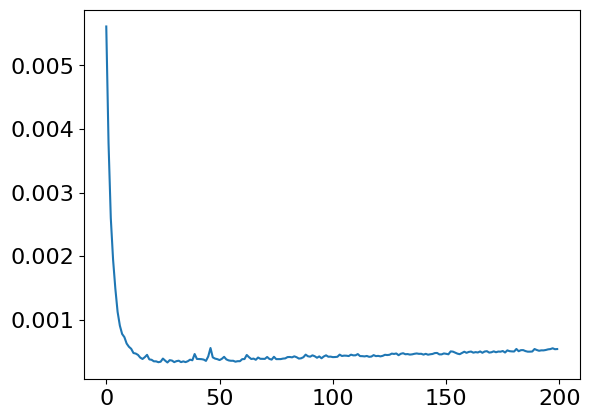

In [532]:
plt.plot(losses[:])
plt.show()

In [87]:
def generate(model, data_tensor, mult: int = 5) -> np.array:
    synth_vae_arr = []

    for _ in range(mult):
        synth_vae_num, synth_vae_logits, _, _ = model(data_tensor.unsqueeze(1).to(device))
        synth_vae_num = synth_vae_num.squeeze(1).detach().cpu().numpy()
        
        cat_arr = []
        for logits in synth_vae_logits:
            cat_arr.append(logits.squeeze(1).softmax(dim=-1).argmax(dim=-1).long().view(-1, 1).detach().cpu().numpy())
        cat_arr = np.hstack(np.array(cat_arr))
        
        synth_vae = np.concatenate([cat_arr, synth_vae_num], axis=1)
        
        synth_vae_arr.append(synth_vae)
        
    synth_vae = np.vstack(np.array(synth_vae_arr))
    
    return synth_vae #(5*N, T)

In [534]:
model_vae.eval()

VAE(
  (cat_heads): ModuleList(
    (0): Linear(in_features=3, out_features=27, bias=True)
  )
  (enc_conv1): Conv1d(1, 16, kernel_size=(3,), stride=(1,), padding=same)
  (enc_bn1): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (enc_res1): ResidualBlock(
    (conv1): Conv1d(16, 16, kernel_size=(3,), stride=(1,), padding=same)
    (bn1): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (conv2): Conv1d(16, 16, kernel_size=(3,), stride=(1,), padding=same)
    (bn2): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (act): SiLU()
    (drop1): Dropout(p=0.1, inplace=False)
    (drop2): Dropout(p=0.1, inplace=False)
  )
  (enc_conv2): Conv1d(16, 16, kernel_size=(3,), stride=(1,), padding=same)
  (enc_bn2): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (enc_res2): ResidualBlock(
    (conv1): Conv1d(16, 16, kernel_size=(3,), stride=(1,), padding=same)
   

In [535]:
synth_vae = generate(model_vae, data_tensor)
synth_vae.shape

(12920, 16)

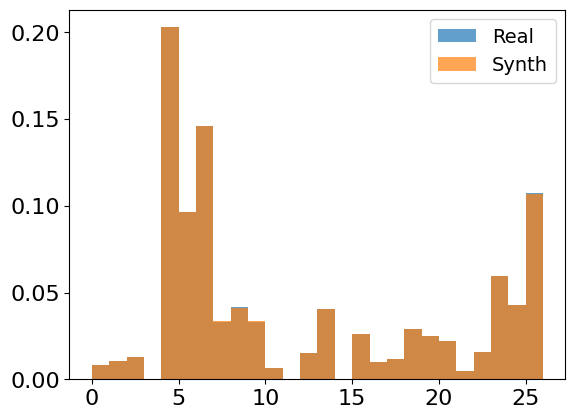

In [536]:
plt.hist(augmented_data[:, 0], bins=np.arange(0, 27), alpha=0.7, density=True, label='Real')
plt.hist(synth_vae[:, 0], bins=np.arange(0, 27), alpha=0.7, density=True, label='Synth')

plt.legend()
plt.show()

/Users/kirillzakharov/Library/Python/3.11/lib/python/site-packages/IPython/core/pylabtools.py:152: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


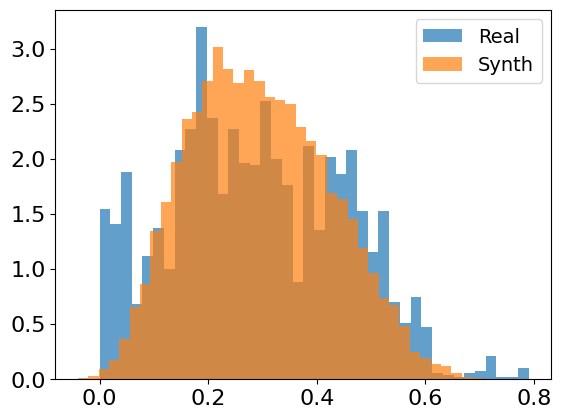

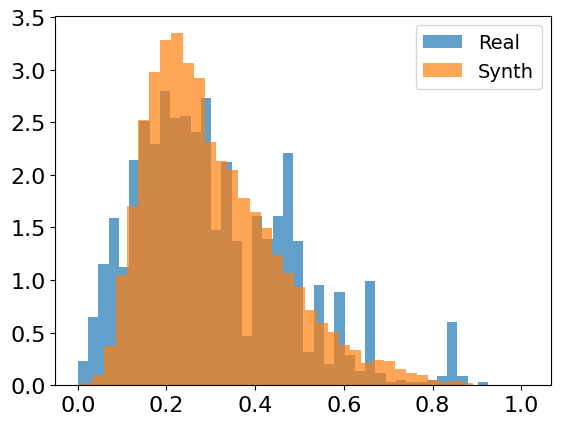

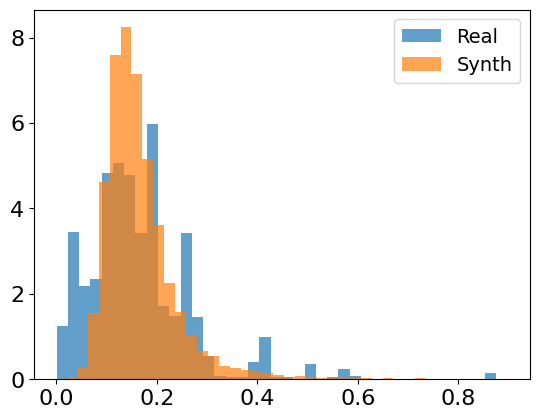

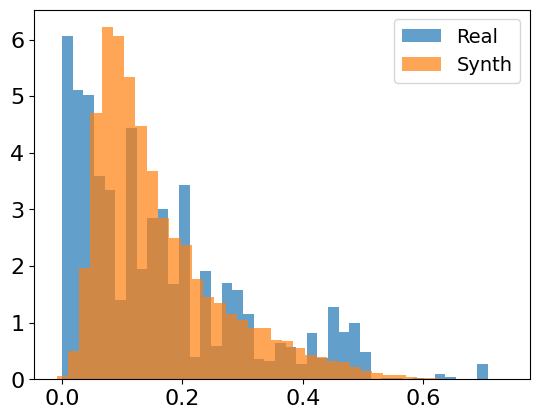

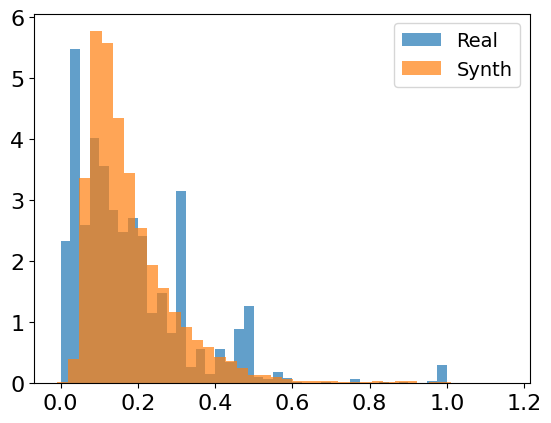

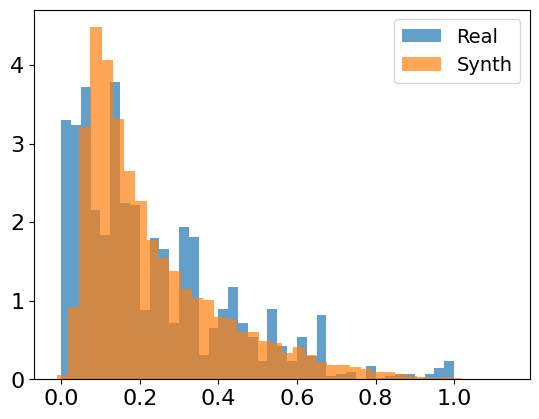

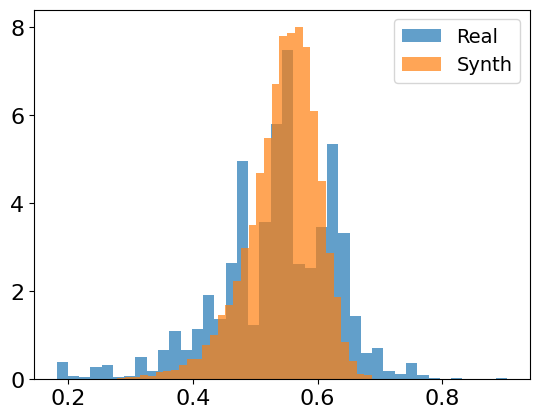

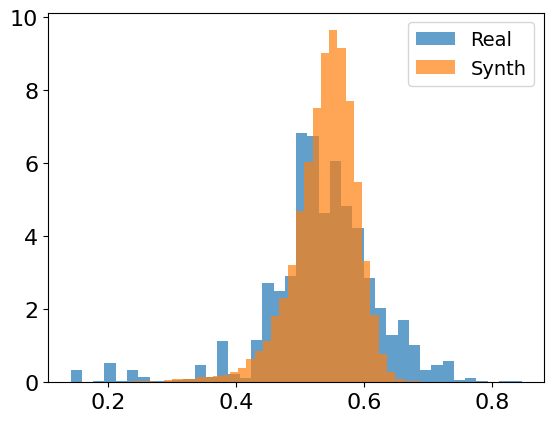

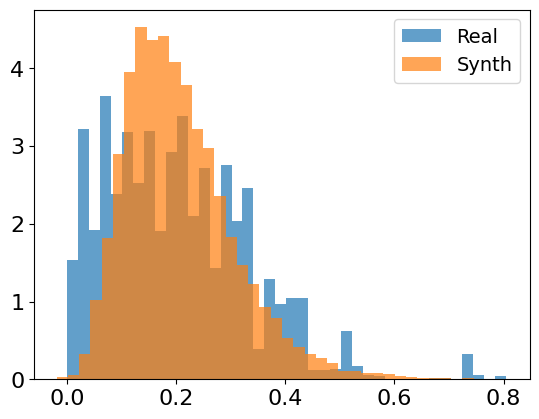

In [537]:
for i in range(1, 10):
    plt.hist(augmented_data[:, i], bins=40, alpha=0.7, density=True, label='Real')
    plt.hist(synth_vae[:, i], bins=40, alpha=0.7, density=True, label='Synth')

    plt.legend()
    plt.show()

In [527]:
# synth_df = pd.DataFrame(np.concatenate([scaler_X_train.inverse_transform(synth_vae[:, :-1]), scaler_y_train.inverse_transform(synth_vae[:, -1].reshape(-1, 1))], axis=1), columns=data.columns)
# synth_df = pd.DataFrame(np.concatenate([scalers['scaler_X'].inverse_transform(synth_vae), scalers['scaler_y'].inverse_transform(data_tensor[:, -1].repeat(5).reshape(-1, 1))], axis=1))
synth_df = pd.DataFrame(np.concatenate([synth_vae, data_tensor[:, -1].repeat(5).reshape(-1, 1)], axis=1))

In [509]:
# plt.figure(figsize=(8, 8))

# plt.scatter(X_ex.iloc[:, 0], X_ex.iloc[:, 1], alpha=0.7, edgecolors='none', s=50, color='tab:blue', label='Good points')
# plt.scatter(best_individuals[:, 0], best_individuals[:, 1], color='green', alpha=0.7, edgecolors='none', s=50, label='GA points')
# plt.scatter(bad_X.iloc[:, 0], bad_X.iloc[:, 1], color='red', alpha=0.7, edgecolors='none', s=50, label='Bad points')
# plt.scatter(synth_df.iloc[:, 0], synth_df.iloc[:, 1], color='purple', alpha=0.5, edgecolors='none', s=50, label='VAE points')

# plt.xlabel('Feature 1')
# plt.ylabel('Feature 2')

# plt.xlim(0, 1)
# plt.ylim(0, 1)
# plt.legend()
# plt.tight_layout(pad=0.5)
# # plt.savefig('images/VAE_points.pdf', dpi=300)
# plt.show()

In [510]:
# bad_data['pricemetr'].hist(bins=40,  alpha=0.7, density=True)
# synth_df['pricemetr'].hist(bins=40, alpha=0.7, density=True)

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(


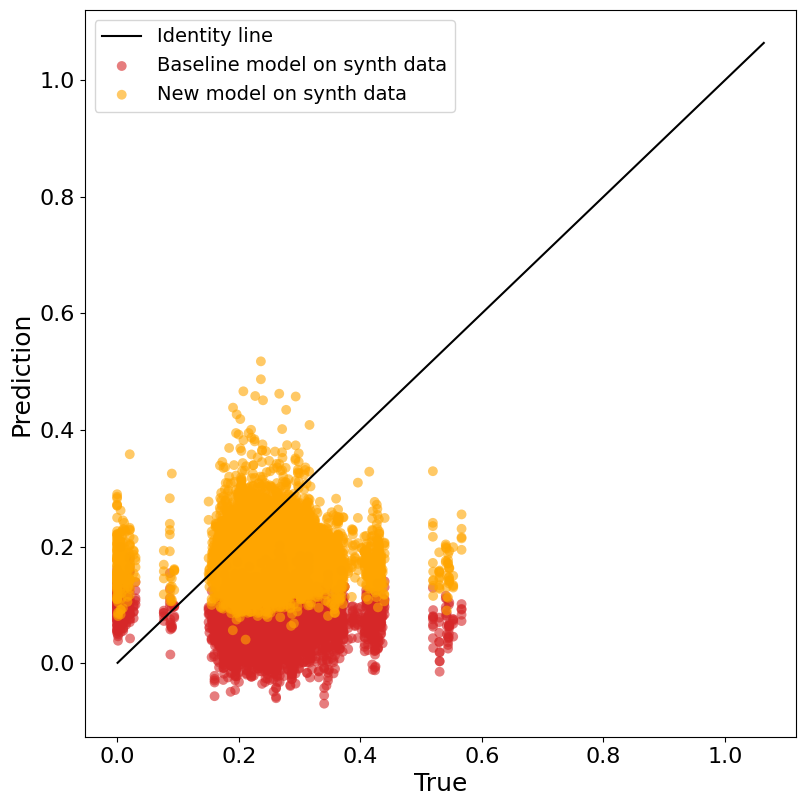

In [511]:
plt.subplots(figsize=(8, 8))
# synth_pred = xgb.predict(synth_df.drop('pricemetr', axis=1))
X_tilde = synth_df.iloc[:, :-1]
X_tilde.columns = X_train.columns

synth_pred = baseline_model.predict(X_tilde)
new_model_synth_pred = new_model.predict(X_tilde)

# plt.scatter(bad_y.values, xgb.predict(bad_X), alpha=0.6, label='Real bad X', color='black')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='black', label='Identity line')
# plt.scatter(augmented_y, baseline_model.predict(augmented_X), alpha=0.6, label='Baseline model on augmented data', color='tab:green', edgecolors='none', s=50)
# plt.scatter(augmented_y, new_model.predict(augmented_X), alpha=0.6, label='New model on augmented data', color='orange', edgecolors='none', s=50)
plt.scatter(synth_df.iloc[:, -1], synth_pred, alpha=0.6, label='Baseline model on synth data', color='tab:red', edgecolors='none', s=50)
plt.scatter(synth_df.iloc[:, -1], new_model_synth_pred, alpha=0.6, label='New model on synth data', color='orange', edgecolors='none', s=50)


plt.xlabel('True')
plt.ylabel('Prediction')
plt.legend()
plt.tight_layout(pad=0.5)
# plt.savefig('images/vae_prediction_moscow.pdf', dpi=300)
plt.show()

In [139]:
# plt.scatter(bad_y, xgb.predict(bad_X), alpha=0.6, label='Synth bad X', color='tab:red')
# plt.scatter(bad_y, new_reg_model.predict(bad_X), alpha=0.6, label='Synth bad X', color='orange')

# plt.scatter(augmented_y, baseline_model.predict(augmented_X), alpha=0.6, label='Augmented bad X', color='tab:red')
# plt.scatter(augmented_y, new_model.predict(augmented_X), alpha=0.6, label='Synth bad X', color='orange')

# plt.show()

In [512]:
mean_squared_error(augmented_y, baseline_model.predict(augmented_X)), mean_squared_error(augmented_y, new_model.predict(augmented_X))

(0.03222953107692364, 0.012642057955041456)

In [513]:
mean_squared_error(bad_y.values.flatten(), baseline_model.predict(bad_X)), mean_squared_error(bad_y.values.flatten(), new_model.predict(bad_X))

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(


(0.02298334186306248, 0.003668193069121187)

In [514]:
mean_squared_error(data_tensor[:, -1].repeat(5).numpy(), synth_pred.flatten()), mean_squared_error(data_tensor[:, -1].repeat(5).numpy(), new_model_synth_pred.flatten())

(0.030948996487001737, 0.008650530129671097)

In [88]:
from scipy.stats import wasserstein_distance

def smape(A, F):
    return 1/len(A) * np.sum(2 * np.abs(F - A) / (np.abs(A) + np.abs(F) + np.finfo(float).eps))

In [272]:
def experiment(X: pd.DataFrame, y: pd.DataFrame, baseline_model, new_model, num_trials: int = 31, alpha: float = 0.1, exp_num = '1'):
    # evaluate_model(XGBRegressor(), X, y)
    
    eval_metrics = {'mse_aug_b': [], 'mse_bad_b': [], 'mse_synth_b': [],
                    'mse_aug_n': [], 'mse_bad_n': [], 'mse_synth_n': [],
                    'mape_aug_b': [], 'mape_bad_b': [], 'mape_synth_b': [],
                    'mape_aug_n': [], 'mape_bad_n': [], 'mape_synth_n': [],
                    'r2_aug_b': [], 'r2_bad_b': [], 'r2_synth_b': [],
                    'r2_aug_n': [], 'r2_bad_n': [], 'r2_synth_n': [],
                    'wd': []}
    
    
    # num_columns = X.select_dtypes(include=[np.number]).columns.tolist()
    # cat_columns = np.setdiff1d(X.columns, num_columns)
    # length_cat_ordinal = len(cat_columns)
    # length_cat_onehot = []
    # length_num = len(num_columns)
    # length_dict = {'length_cat_ordinal': length_cat_ordinal, 'length_cat_onehot': length_cat_onehot, 'length_num': length_num}
    
    num_columns = np.setdiff1d(X.columns, ['Квартиры среднего качества (типовые)'])
    cat_columns = ['Квартиры среднего качества (типовые)']
    length_cat_ordinal = len(cat_columns)
    # length_cat_onehot = []
    length_num = len(num_columns)

    length_dict = {'length_cat_ordinal': length_cat_ordinal, 'length_cat_onehot': [], 'length_num': length_num}
    
    
    for i in range(num_trials):
        try:
            X_train, X_test, y_train, y_test, scalers = split_and_transform(X, y)
            baseline_model = train_model(baseline_model, X_train, y_train)
            new_model = train_model(new_model, X_train, y_train)
            baseline_prediction = baseline_model.predict(X_test).flatten()
            
            bad_X, bad_y = select_bad_examples(X_test, y_test, baseline_prediction, alpha)
            
            lr = LinearRegression(fit_intercept=False)
            lr.fit(X_train.values, y_train.values)
            linear_coefs = lr.coef_[0]
            
  
            best_individuals, bad_y_sc_arr = augmentation(bad_X, bad_y, baseline_model, linear_coefs, length_dict, num_steps=2)
            
            bad_X_ga, bad_y_ga = select_bad_examples(pd.DataFrame(best_individuals), pd.DataFrame(bad_y_sc_arr), baseline_model.predict(best_individuals))
            
            idx_rnd = np.arange(len(bad_X) + len(bad_X_ga))
            np.random.shuffle(idx_rnd)

            augmented_X = np.concatenate([bad_X.values, bad_X_ga.values])[idx_rnd]
            augmented_y = np.concatenate([bad_y.values.flatten(), bad_y_ga.values.flatten()])[idx_rnd]
            augmented_data = np.concatenate([augmented_X, augmented_y.reshape(-1, 1)], axis=1)
            
            
            data_tensor = np.array(augmented_data).astype('float32')
            data_tensor = torch.tensor(data_tensor)
            
            model_vae, _ = train_vae(data_tensor, num_epochs=2, batch_size=2**8, cat_target_flag=True)
            model_vae.eval()
            
            synth_vae = generate(model_vae, data_tensor)
            # synth_df = pd.DataFrame(np.concatenate([scalers['scaler_X'].inverse_transform(synth_vae),
                                                    # scalers['scaler_y'].inverse_transform(data_tensor[:, -1].repeat(10).reshape(-1, 1))], axis=1))
            wd = np.mean(list(map(lambda x, y: wasserstein_distance(x, y), synth_vae.T, augmented_data.T)))
            eval_metrics['wd'].append(wd)
                                                    
            synth_df = pd.DataFrame(np.concatenate([synth_vae, data_tensor[:, -1].repeat(5).reshape(-1, 1)], axis=1))
            
            # synth_pred = baseline_model.predict(synth_df.drop(2, axis=1))
            # new_model_synth_pred = new_model.predict(synth_df.drop(2, axis=1))
            
            X_tilde = synth_df.iloc[:, :-1]
            X_tilde.columns = X_train.columns

            synth_pred = baseline_model.predict(X_tilde)
            new_model_synth_pred = new_model.predict(X_tilde)
            
            np.savez(f'Checkpoints/baseline_pred_exp{exp_num}_iter_{i+1}.npz', bad=baseline_model.predict(bad_X).flatten(), aug=baseline_model.predict(augmented_X).flatten(), synth=synth_pred.flatten())
            np.savez(f'Checkpoints/new_model_pred_exp{exp_num}_iter_{i+1}.npz', bad=new_model.predict(bad_X).flatten(), aug=new_model.predict(augmented_X).flatten(), synth=new_model_synth_pred.flatten())
            np.savez(f'Checkpoints/data_exp{exp_num}_iter_{i+1}.npz', bad=bad_y.values.flatten(), aug=augmented_y.flatten(), synth=data_tensor[:, -1].repeat(5).numpy().flatten())
            
            
            
            mse_aug_b = mean_squared_error(augmented_y.flatten(), baseline_model.predict(augmented_X).flatten())
            mse_bad_b = mean_squared_error(bad_y.values.flatten(), baseline_model.predict(bad_X).flatten())
            mse_synth_b = mean_squared_error(data_tensor[:, -1].repeat(5).numpy().flatten(), synth_pred.flatten())
            
            mse_aug_n = mean_squared_error(augmented_y.flatten(), new_model.predict(augmented_X).flatten())
            mse_bad_n = mean_squared_error(bad_y.values.flatten(), new_model.predict(bad_X).flatten())
            mse_synth_n = mean_squared_error(data_tensor[:, -1].repeat(5).numpy().flatten(), new_model_synth_pred.flatten())
            
            
            mape_aug_b = smape(augmented_y.flatten(), baseline_model.predict(augmented_X).flatten())
            mape_bad_b = smape(bad_y.values.flatten(), baseline_model.predict(bad_X).flatten())
            mape_synth_b = smape(data_tensor[:, -1].repeat(5).numpy().flatten(), synth_pred.flatten())

            mape_aug_n = smape(augmented_y.flatten(), new_model.predict(augmented_X).flatten())
            mape_bad_n = smape(bad_y.values.flatten(), new_model.predict(bad_X).flatten())
            mape_synth_n = smape(data_tensor[:, -1].repeat(5).numpy().flatten(), new_model_synth_pred.flatten())
        

            # mape_aug = mean_absolute_percentage_error(augmented_y, baseline_model.predict(augmented_X)), mean_squared_error(augmented_y, new_model.predict(augmented_X))
            # mape_bad = mean_absolute_percentage_error(bad_y.values.flatten(), baseline_model.predict(bad_X)), mean_squared_error(bad_y.values.flatten(), new_model.predict(bad_X))
            # mape_synth = mean_absolute_percentage_error(data_tensor[:, -1].repeat(10).numpy(), synth_pred.flatten()), mean_squared_error(data_tensor[:, -1].repeat(10).numpy(), new_model_synth_pred.flatten())
            
            # r2_aug = r2_score(augmented_y, baseline_model.predict(augmented_X)), mean_squared_error(augmented_y, new_model.predict(augmented_X))
            # r2_bad = r2_score(bad_y.values.flatten(), baseline_model.predict(bad_X)), mean_squared_error(bad_y.values.flatten(), new_model.predict(bad_X))
            # r2_synth = r2_score(data_tensor[:, -1].repeat(5).numpy(), synth_pred.flatten()), mean_squared_error(data_tensor[:, -1].repeat(5).numpy(), new_model_synth_pred.flatten())
            
            r2_aug_b = r2_score(augmented_y.flatten(), baseline_model.predict(augmented_X).flatten())
            r2_bad_b = r2_score(bad_y.values.flatten(), baseline_model.predict(bad_X).flatten())
            r2_synth_b = r2_score(data_tensor[:, -1].repeat(5).numpy().flatten(), synth_pred.flatten())
            
            r2_aug_n = r2_score(augmented_y.flatten(), new_model.predict(augmented_X).flatten())
            r2_bad_n = r2_score(bad_y.values.flatten(), new_model.predict(bad_X).flatten())
            r2_synth_n = r2_score(data_tensor[:, -1].repeat(5).numpy().flatten(), new_model_synth_pred.flatten())
            
            
        
            
            eval_metrics['mse_aug_b'].append(mse_aug_b)
            eval_metrics['mse_bad_b'].append(mse_bad_b)
            eval_metrics['mse_synth_b'].append(mse_synth_b)
            
            eval_metrics['mse_aug_n'].append(mse_aug_n)
            eval_metrics['mse_bad_n'].append(mse_bad_n)
            eval_metrics['mse_synth_n'].append(mse_synth_n)
            

            eval_metrics['mape_aug_b'].append(mape_aug_b)
            eval_metrics['mape_bad_b'].append(mape_bad_b)
            eval_metrics['mape_synth_b'].append(mape_synth_b)

            eval_metrics['mape_aug_n'].append(mape_aug_n)
            eval_metrics['mape_bad_n'].append(mape_bad_n)
            eval_metrics['mape_synth_n'].append(mape_synth_n)

            
            eval_metrics['r2_aug_b'].append(r2_aug_b)
            eval_metrics['r2_bad_b'].append(r2_bad_b)
            eval_metrics['r2_synth_b'].append(r2_synth_b)
            
            eval_metrics['r2_aug_n'].append(r2_aug_n)
            eval_metrics['r2_bad_n'].append(r2_bad_n)
            eval_metrics['r2_synth_n'].append(r2_synth_n)
            
        except Exception as e:
            print(e)
            continue
        
    np.save(f'Checkpoints/eval_metrics_exp{exp_num}.npy', eval_metrics)
        
    eval_df_baseline = pd.DataFrame([
                            [f"{np.mean(eval_metrics['mse_aug_b']):.4f}+-{np.std(eval_metrics['mse_aug_b']):.4f}", 
                            f"{np.mean(eval_metrics['mse_bad_b']):.4f}+-{np.std(eval_metrics['mse_bad_b']):.4f}",
                            f"{np.mean(eval_metrics['mse_synth_b']):.4f}+-{np.std(eval_metrics['mse_synth_b']):.4f}"], 
                            
                            [f"{np.mean(eval_metrics['mape_aug_b']):.4f}+-{np.std(eval_metrics['mape_aug_b']):.4f}", 
                            f"{np.mean(eval_metrics['mape_bad_b']):.4f}+-{np.std(eval_metrics['mape_bad_b']):.4f}",
                            f"{np.mean(eval_metrics['mape_synth_b']):.4f}+-{np.std(eval_metrics['mape_synth_b']):.4f}"],
                            
                            [f"{np.mean(eval_metrics['r2_aug_b']):.4f}+-{np.std(eval_metrics['r2_aug_b']):.4f}", 
                            f"{np.mean(eval_metrics['r2_bad_b']):.4f}+-{np.std(eval_metrics['r2_bad_b']):.4f}",
                            f"{np.mean(eval_metrics['r2_synth_b']):.4f}+-{np.std(eval_metrics['r2_synth_b']):.4f}"],
                            
                            ["-",
                            "-",
                            f"{np.mean(eval_metrics['wd']):.4f}+-{np.std(eval_metrics['wd']):.4f}"],
                            
                            ],
                        columns=['AUG, MEAN+STD', 'BAD, MEAN+STD', 'SYNTH, MEAN+STD'], index=['mse', 'smape', 'r2', 'wd'])
    
    eval_df_new = pd.DataFrame([
                            [f"{np.mean(eval_metrics['mse_aug_n']):.4f}+-{np.std(eval_metrics['mse_aug_n']):.4f}", 
                            f"{np.mean(eval_metrics['mse_bad_n']):.4f}+-{np.std(eval_metrics['mse_bad_n']):.4f}",
                            f"{np.mean(eval_metrics['mse_synth_n']):.4f}+-{np.std(eval_metrics['mse_synth_n']):.4f}"], 
                            
                            [f"{np.mean(eval_metrics['mape_aug_n']):.4f}+-{np.std(eval_metrics['mape_aug_n']):.4f}", 
                            f"{np.mean(eval_metrics['mape_bad_n']):.4f}+-{np.std(eval_metrics['mape_bad_n']):.4f}",
                            f"{np.mean(eval_metrics['mape_synth_n']):.4f}+-{np.std(eval_metrics['mape_synth_n']):.4f}"],
                            
                            [f"{np.mean(eval_metrics['r2_aug_n']):.4f}+-{np.std(eval_metrics['r2_aug_n']):.4f}", 
                            f"{np.mean(eval_metrics['r2_bad_n']):.4f}+-{np.std(eval_metrics['r2_bad_n']):.4f}",
                            f"{np.mean(eval_metrics['r2_synth_n']):.4f}+-{np.std(eval_metrics['r2_synth_n']):.4f}"],
                            
                            ["-",
                            "-",
                            f"{np.mean(eval_metrics['wd']):.4f}+-{np.std(eval_metrics['wd']):.4f}"],
                            
                            ],
                        columns=['AUG, MEAN+STD', 'BAD, MEAN+STD', 'SYNTH, MEAN+STD'], index=['mse', 'smape', 'r2', 'wd'])
        
    eval_df_baseline.to_csv(f'Checkpoints/eval_df_baseline_exp{exp_num}.csv', header=True, index=True)
    eval_df_new.to_csv(f'Checkpoints/eval_df_new_exp{exp_num}.csv', header=True, index=True)
    
    return eval_df_baseline, eval_df_new

In [273]:
# baseline_model = train_model(LinearRegression(), X_train, y_train)
# new_model = train_model(XGBRegressor(), X_train, y_train)

In [274]:
(5*60*15 + 3*20)/60/60

1.2666666666666666

In [275]:
import warnings
warnings.filterwarnings("ignore")

In [276]:
alphas = [0.1, 0.3]

In [277]:
for i, alpha in enumerate(alphas):
    eval_df_baseline, eval_df_new = experiment(X_ex, y_ex, LinearRegression(), XGBRegressor(), num_trials=2, alpha=alpha, exp_num=f'_alpha_{i+1}')

Average Loss: 0.0143, LR: 0.0006: 100%|██████████| 2/2 [00:00<00:00, 37.75it/s]


In [278]:
# eval_df_baseline, eval_df_new = experiment(X_ex, y_ex, LinearRegression(), XGBRegressor(), num_trials=15, alpha=0.1)

In [279]:
# eval_df_baseline

In [280]:
# eval_df_new

In [281]:
np.load('Checkpoints/eval_metrics_exp_alpha_2.npy', allow_pickle=True).item()['mape_aug_b']

[1.6561633326970466, 1.7057903470462998]

In [282]:
np.load('Checkpoints/baseline_pred_exp_alpha_1_iter_1.npz')['aug']

array([ 0.12769711,  0.092635  ,  0.06363845,  0.08823166,  0.11217153,
        0.07690176,  0.09156469,  0.07912868,  0.07878458,  0.07353533,
        0.0800577 ,  0.10515046,  0.07609421,  0.15967819,  0.07923213,
        0.08390508,  0.06208927,  0.1152141 ,  0.08580093,  0.08932063,
        0.09980351,  0.00462428,  0.05444966,  0.08482862,  0.06506172,
        0.10274224,  0.0977529 ,  0.15079653,  0.07563449,  0.11707411,
        0.09900823,  0.03197974,  0.05065078,  0.08178256,  0.15588025,
        0.02249031,  0.10461544,  0.0075957 ,  0.12515227,  0.15339688,
        0.02407671,  0.0558658 ,  0.12135745,  0.15507825,  0.03136888,
        0.07594412,  0.12189241,  0.13784361, -0.0365775 ,  0.07184847,
        0.05507553,  0.04115282,  0.11083244,  0.05180084,  0.04528349,
        0.06651123,  0.03908645,  0.04540216,  0.07607799,  0.09368521,
       -0.00710439,  0.06804195, -0.00161706,  0.07789755,  0.10843436,
        0.14597536,  0.08909611,  0.11266757,  0.10550197,  0.07

In [285]:
np.load('Checkpoints/baseline_pred_exp_alpha_1_iter_1.npz')['bad']

array([0.10860026, 0.06908608, 0.06628548, 0.10960473, 0.08071154,
       0.10073509, 0.14163065, 0.12515227, 0.0883262 , 0.14755414,
       0.1556938 , 0.08611268, 0.07729916, 0.10205999, 0.08570011,
       0.12640344, 0.10762073, 0.08721184, 0.09083076, 0.07723713,
       0.10543268, 0.07191877, 0.06804195, 0.0916027 , 0.107332  ,
       0.0731723 , 0.08337232, 0.10743056, 0.12683874, 0.07526239,
       0.12009489, 0.12061128, 0.0693235 , 0.11117436, 0.07221092,
       0.09368521, 0.11266307, 0.07718744, 0.06761496, 0.08663092,
       0.15498695, 0.09681022, 0.06499249, 0.06204886, 0.06337287,
       0.10041896, 0.1044362 , 0.15772734, 0.06806543, 0.06619692,
       0.11386673, 0.07410631, 0.122036  , 0.07928091, 0.12032291,
       0.1166912 , 0.12199293, 0.10795038, 0.11361642, 0.15507825,
       0.06802507, 0.09844175, 0.11313317, 0.09593303, 0.06506172,
       0.06208927, 0.06572096, 0.07579732, 0.07730874, 0.1131139 ,
       0.10013446, 0.10502713, 0.06512722, 0.07446715, 0.10481

In [288]:
np.load('Checkpoints/data_exp_alpha_2_iter_1.npz')['bad']

array([0.51588326, 0.72255571, 0.84212003, 1.06368212, 0.44585834,
       0.48793873, 0.40354092, 0.62794985, 0.40556158])

In [ ]:
# 1 - np.var(np.load('Checkpoints/data_0.npz')['arr_2'] - np.load('Checkpoints/baseline_pred_0.npz')['arr_2']) / np.var(np.load('Checkpoints/data_0.npz')['arr_2'])

-0.0010396931156120282

In [289]:
pd.read_csv('Checkpoints/eval_df_baseline_exp_alpha_1.csv')

,Unnamed: 0,"AUG, MEAN+STD","BAD, MEAN+STD","SYNTH, MEAN+STD"
0,mse,0.0316+-0.0013,0.0254+-0.0008,0.0341+-0.0003
1,smape,1.0314+-0.0023,0.8834+-0.0048,1.0987+-0.0418
2,r2,-5.6367+-0.3485,-4.3040+-0.2059,-6.1935+-0.7416
3,wd,-,-,0.7453+-0.0853


In [290]:
pd.read_csv('Checkpoints/eval_df_new_exp_alpha_1.csv')

,Unnamed: 0,"AUG, MEAN+STD","BAD, MEAN+STD","SYNTH, MEAN+STD"
0,mse,0.0136+-0.0008,0.0079+-0.0007,0.0247+-0.0075
1,smape,0.4653+-0.0123,0.2681+-0.0129,0.8280+-0.1852
2,r2,-1.8486+-0.0924,-0.6462+-0.0373,-4.0517+-1.0964
3,wd,-,-,0.7453+-0.0853
